# v2 — Step 01: Load and Validate Raw Counts

## Purpose
Load the 9 per-sample raw count matrices recovered from the original 10x Genomics BAM files,
validate they contain true integer UMI counts (not pre-normalized floats), merge into a single
AnnData object, and save a verified checkpoint.

## Why we recovered raw counts
The GEO-provided `GSE116222_Expression_matrix.txt.gz` contains **pre-normalized, log-transformed
values** — not raw counts. Applying `sc.pp.normalize_total()` to already-normalized data
produces double normalization. All downstream results from that approach are unreliable.
Raw counts were recovered directly from the SRA BAM files using UMI deduplication.

## Inputs
- `data/recovered_raw_counts/h5ad/{sample}_raw_counts.h5ad` × 9 samples

## Output
- `data/processed/v2/GSE116222_v2_raw.h5ad` — merged, validated raw counts

In [15]:
import os
import gc
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse

sc.settings.set_figure_params(dpi=300, facecolor='white', frameon=False)
os.chdir("/Users/Vicky/vicky/UC_Single_Cell_analysis")
print("cwd:", os.getcwd())
os.makedirs('figures/v2', exist_ok=True)
os.makedirs('data/processed/v2', exist_ok=True)

print(f"scanpy  : {sc.__version__}")
print(f"anndata : {ad.__version__}")

cwd: /Users/Vicky/vicky/UC_Single_Cell_analysis
scanpy  : 1.9.8
anndata : 0.11.4


## Load per-sample h5ad files

Each file contains one sample recovered from 10x BAM data.
Cell barcodes already carry a unique sample suffix (e.g., `-A1`, `-B3`) so they are
globally unique across samples — no renaming needed before merge.

| Sample | Condition | Patient |
|--------|-----------|---------|
| A1_healthy | Healthy | A |
| A2_non_inflamed | UC non-inflamed | A |
| A3_inflamed | UC inflamed | A |
| B1_healthy | Healthy | B |
| B2_non_inflamed | UC non-inflamed | B |
| B3_inflamed | UC inflamed | B |
| C1_healthy | Healthy | C |
| C2_non_inflamed | UC non-inflamed | C |
| C3_inflamed | UC inflamed | C |

In [6]:
h5ad_dir = 'data/recovered_raw_counts/h5ad'

sample_order = [
    'A1_healthy', 'A2_non_inflamed', 'A3_inflamed',
    'B1_healthy', 'B2_non_inflamed', 'B3_inflamed',
    'C1_healthy', 'C2_non_inflamed', 'C3_inflamed'
]

adatas = {}
for sample in sample_order:
    fpath = os.path.join(h5ad_dir, f'{sample}_raw_counts.h5ad')
    adata = sc.read_h5ad(fpath)
    adatas[sample] = adata
    print(f"  {sample:25s} {adata.n_obs:5d} cells × {adata.n_vars:5d} genes  "
          f"condition={adata.obs['condition'].iloc[0]}  batch={adata.obs['batch'].iloc[0]}")

  A1_healthy                  482 cells × 58690 genes  condition=Healthy  batch=A
  A2_non_inflamed             372 cells × 58690 genes  condition=UC_noninflamed  batch=A
  A3_inflamed                 535 cells × 58690 genes  condition=UC_inflamed  batch=A
  B1_healthy                 1621 cells × 58690 genes  condition=Healthy  batch=B
  B2_non_inflamed            1980 cells × 58690 genes  condition=UC_noninflamed  batch=B
  B3_inflamed                1039 cells × 58690 genes  condition=UC_inflamed  batch=B
  C1_healthy                 2146 cells × 58690 genes  condition=Healthy  batch=C
  C2_non_inflamed            1726 cells × 58690 genes  condition=UC_noninflamed  batch=C
  C3_inflamed                1274 cells × 58690 genes  condition=UC_inflamed  batch=C


## Validate raw count integrity

Before merging we confirm each file contains true raw UMI counts:
1. **dtype** — should be `int32` or `int64`
2. **Integer-valued** — no decimal fractions (pre-normalized data has fractional values)
3. **Non-negative** — UMI counts cannot be negative
4. **Non-uniform cell sums** — if every cell has the same total, the data was normalised;
   raw counts have a wide spread of library sizes
5. **Plausible UMI range** — 10x Chromium 3′ v2 typically yields 1,000–20,000 UMIs/cell

In [7]:
print("=" * 60)
print("RAW COUNT VALIDATION")
print("=" * 60)

all_pass = True
for sample, adata in adatas.items():
    X = adata.X
    vals = X.data if issparse(X) else X.flatten()
    cell_sums = np.array(X.sum(axis=1)).flatten()

    is_int_dtype  = np.issubdtype(X.dtype, np.integer)
    is_int_valued = bool(np.all(vals == np.floor(vals)))
    is_nonneg     = bool(np.all(vals >= 0))
    # Coefficient of variation of cell sums — near 0 means uniform (pre-normalised)
    cv_sums       = cell_sums.std() / cell_sums.mean()
    uniform_flag  = cv_sums < 0.05

    status = 'PASS' if (is_int_dtype and is_int_valued and is_nonneg and not uniform_flag) else 'FAIL'
    if status == 'FAIL':
        all_pass = False

    print(f"\n{sample} [{status}]")
    print(f"  dtype        : {X.dtype}")
    print(f"  int dtype    : {is_int_dtype}")
    print(f"  int-valued   : {is_int_valued}")
    print(f"  non-negative : {is_nonneg}")
    print(f"  UMI range    : {int(vals.min())} – {int(vals.max())}")
    print(f"  cells sums   : min={int(cell_sums.min())}  max={int(cell_sums.max())}  CV={cv_sums:.3f}")
    print(f"  uniform sums : {uniform_flag}  (True = likely pre-normalised — BAD)")

print("\n" + "=" * 60)
print(f"Overall validation: {'ALL PASS ✓' if all_pass else 'ONE OR MORE SAMPLES FAILED — investigate before proceeding'}")
print("=" * 60)

RAW COUNT VALIDATION

A1_healthy [PASS]
  dtype        : int32
  int dtype    : True
  int-valued   : True
  non-negative : True
  UMI range    : 1 – 3600
  cells sums   : min=2016  max=26961  CV=0.715
  uniform sums : False  (True = likely pre-normalised — BAD)

A2_non_inflamed [PASS]
  dtype        : int32
  int dtype    : True
  int-valued   : True
  non-negative : True
  UMI range    : 1 – 2277
  cells sums   : min=2030  max=42286  CV=0.913
  uniform sums : False  (True = likely pre-normalised — BAD)

A3_inflamed [PASS]
  dtype        : int32
  int dtype    : True
  int-valued   : True
  non-negative : True
  UMI range    : 1 – 3976
  cells sums   : min=2020  max=13245  CV=0.513
  uniform sums : False  (True = likely pre-normalised — BAD)

B1_healthy [PASS]
  dtype        : int32
  int dtype    : True
  int-valued   : True
  non-negative : True
  UMI range    : 1 – 4005
  cells sums   : min=2037  max=18138  CV=0.627
  uniform sums : False  (True = likely pre-normalised — BAD)

B2_n

## Merge all samples into a single AnnData object

We use `anndata.concat()` with `join='inner'` to retain only genes present in **all** samples.
Since all 9 samples were extracted from the same reference genome (GRCh38, 58,690 genes),
the gene sets should be identical and no genes will be lost.

Metadata columns (`sample`, `condition`, `batch`) are preserved as-is from each per-sample object.

In [8]:
adata_list = [adatas[s] for s in sample_order]

merged = ad.concat(adata_list, axis=0, join='inner', merge='first')
merged.obs_names_make_unique()

print(f"Merged AnnData: {merged.n_obs:,} cells × {merged.n_vars:,} genes")
print(f"\nCell counts per sample:")
print(merged.obs.groupby(['batch', 'condition', 'sample']).size().rename('n_cells').to_string())

Merged AnnData: 11,175 cells × 58,690 genes

Cell counts per sample:
batch  condition       sample         
A      Healthy         A1_healthy          482
                       A2_non_inflamed       0
                       A3_inflamed           0
                       B1_healthy            0
                       B2_non_inflamed       0
                       B3_inflamed           0
                       C1_healthy            0
                       C2_non_inflamed       0
                       C3_inflamed           0
       UC_inflamed     A1_healthy            0
                       A2_non_inflamed       0
                       A3_inflamed         535
                       B1_healthy            0
                       B2_non_inflamed       0
                       B3_inflamed           0
                       C1_healthy            0
                       C2_non_inflamed       0
                       C3_inflamed           0
       UC_noninflamed  A1_healthy            0

/var/folders/mr/f3825hy10rjbrjd_85fs57bc0000gp/T/ipykernel_34410/3097123921.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(merged.obs.groupby(['batch', 'condition', 'sample']).size().rename('n_cells').to_string())


In [9]:
# Free per-sample objects from memory
del adatas, adata_list
gc.collect()
print("Memory freed.")

Memory freed.


## Visualise pre-QC cell counts per sample

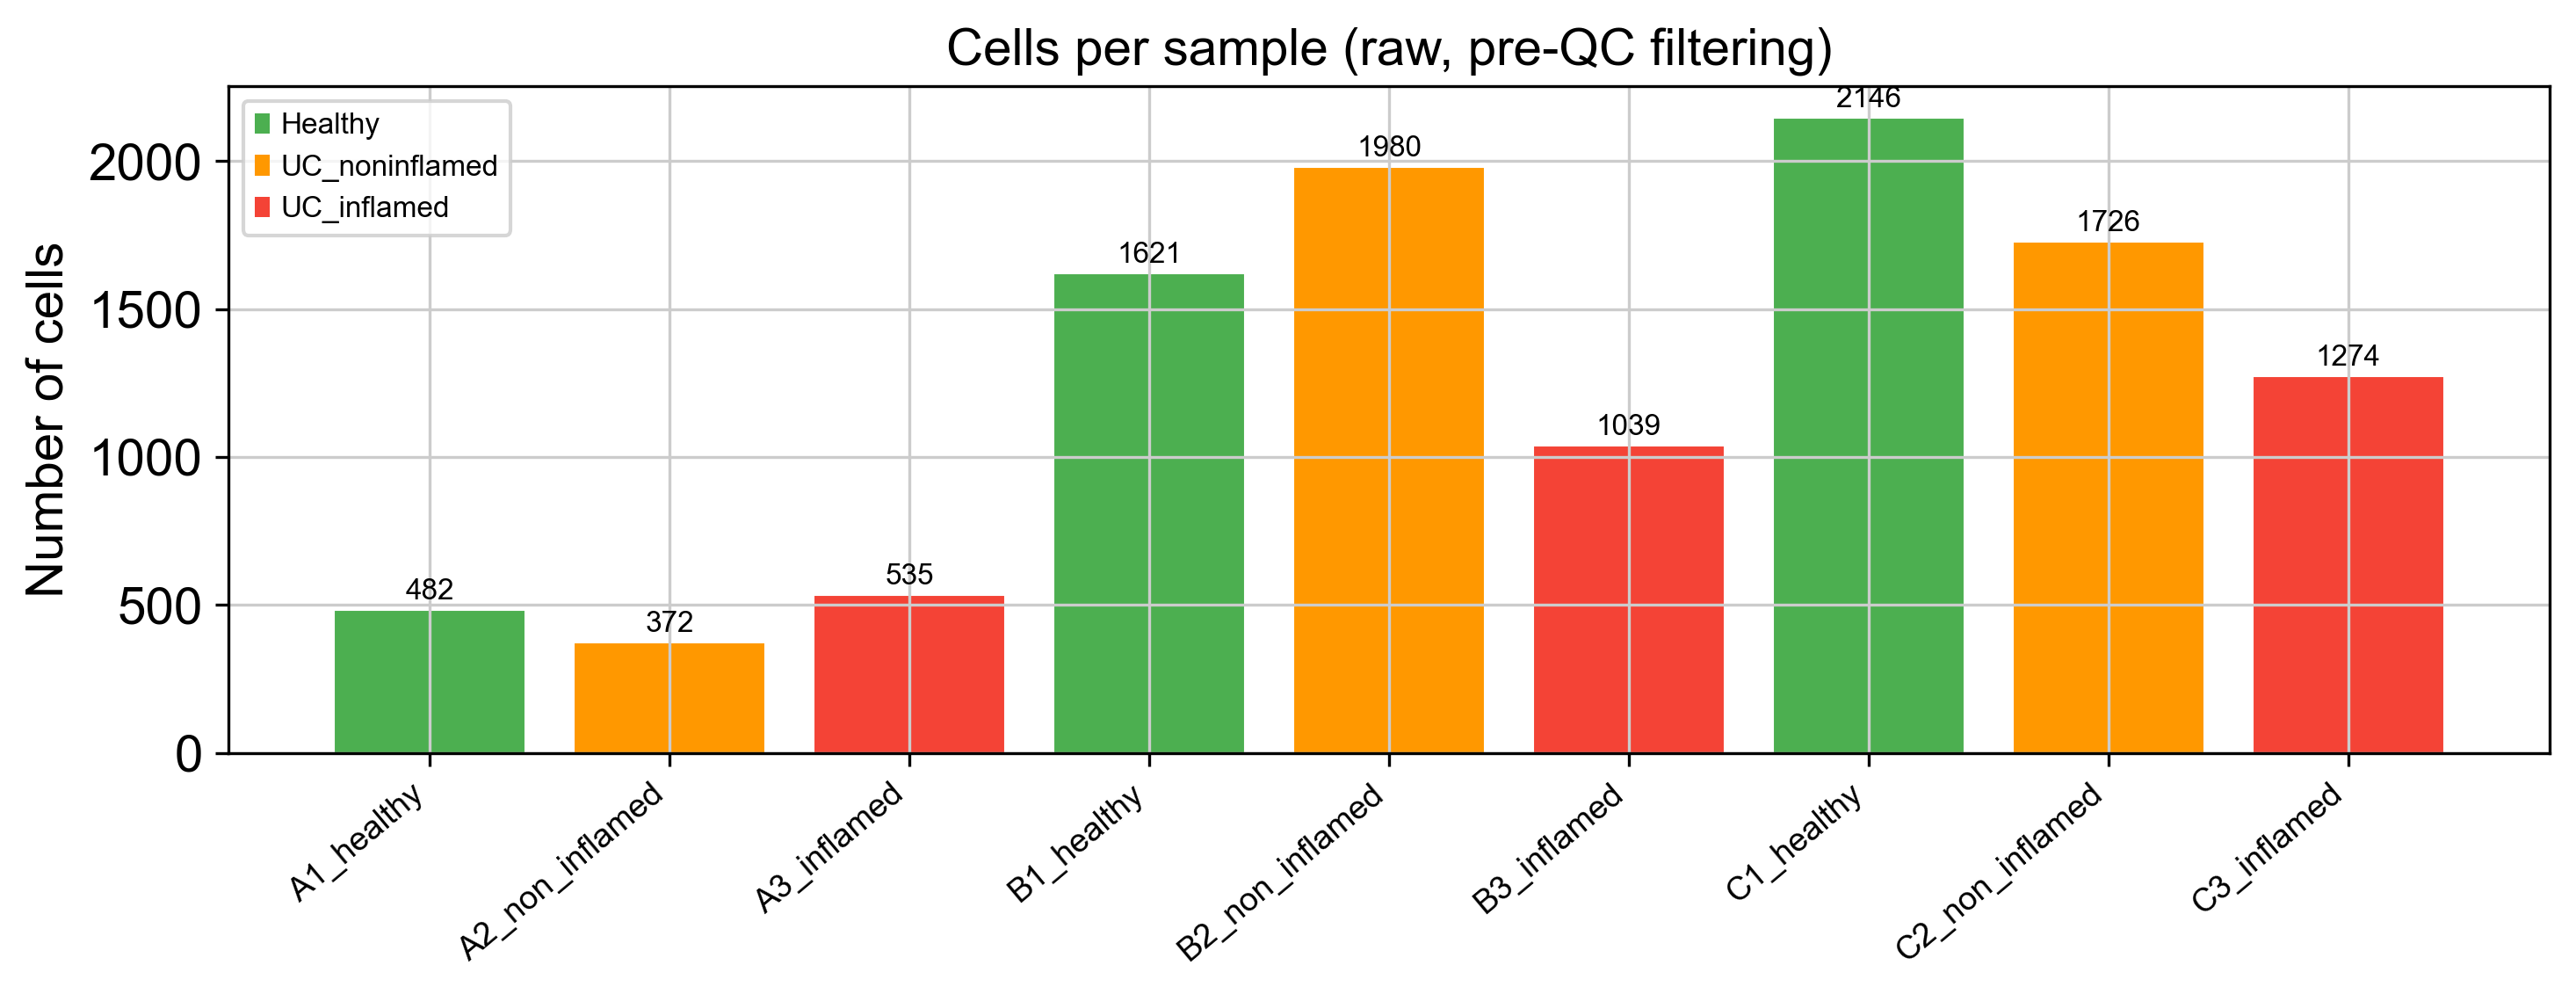

In [10]:
counts_per_sample = merged.obs['sample'].value_counts()[sample_order]

# Colour by condition
condition_colours = {'Healthy': '#4CAF50', 'UC_noninflamed': '#FF9800', 'UC_inflamed': '#F44336'}
bar_colours = [
    condition_colours[merged.obs[merged.obs['sample'] == s]['condition'].iloc[0]]
    for s in sample_order
]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(sample_order)), counts_per_sample.values, color=bar_colours, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(sample_order)))
ax.set_xticklabels(sample_order, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Number of cells')
ax.set_title('Cells per sample (raw, pre-QC filtering)')

# Add count labels on bars
for bar, val in zip(bars, counts_per_sample.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15, str(val),
            ha='center', va='bottom', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in condition_colours.items()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('figures/v2/01_cells_per_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## Validate UMI distributions (pre-QC)

If data were pre-normalised, every cell would have the same total UMI count (or close to it).
Raw UMI counts show a wide, right-skewed distribution — the violin widths should vary substantially
both within and between samples.

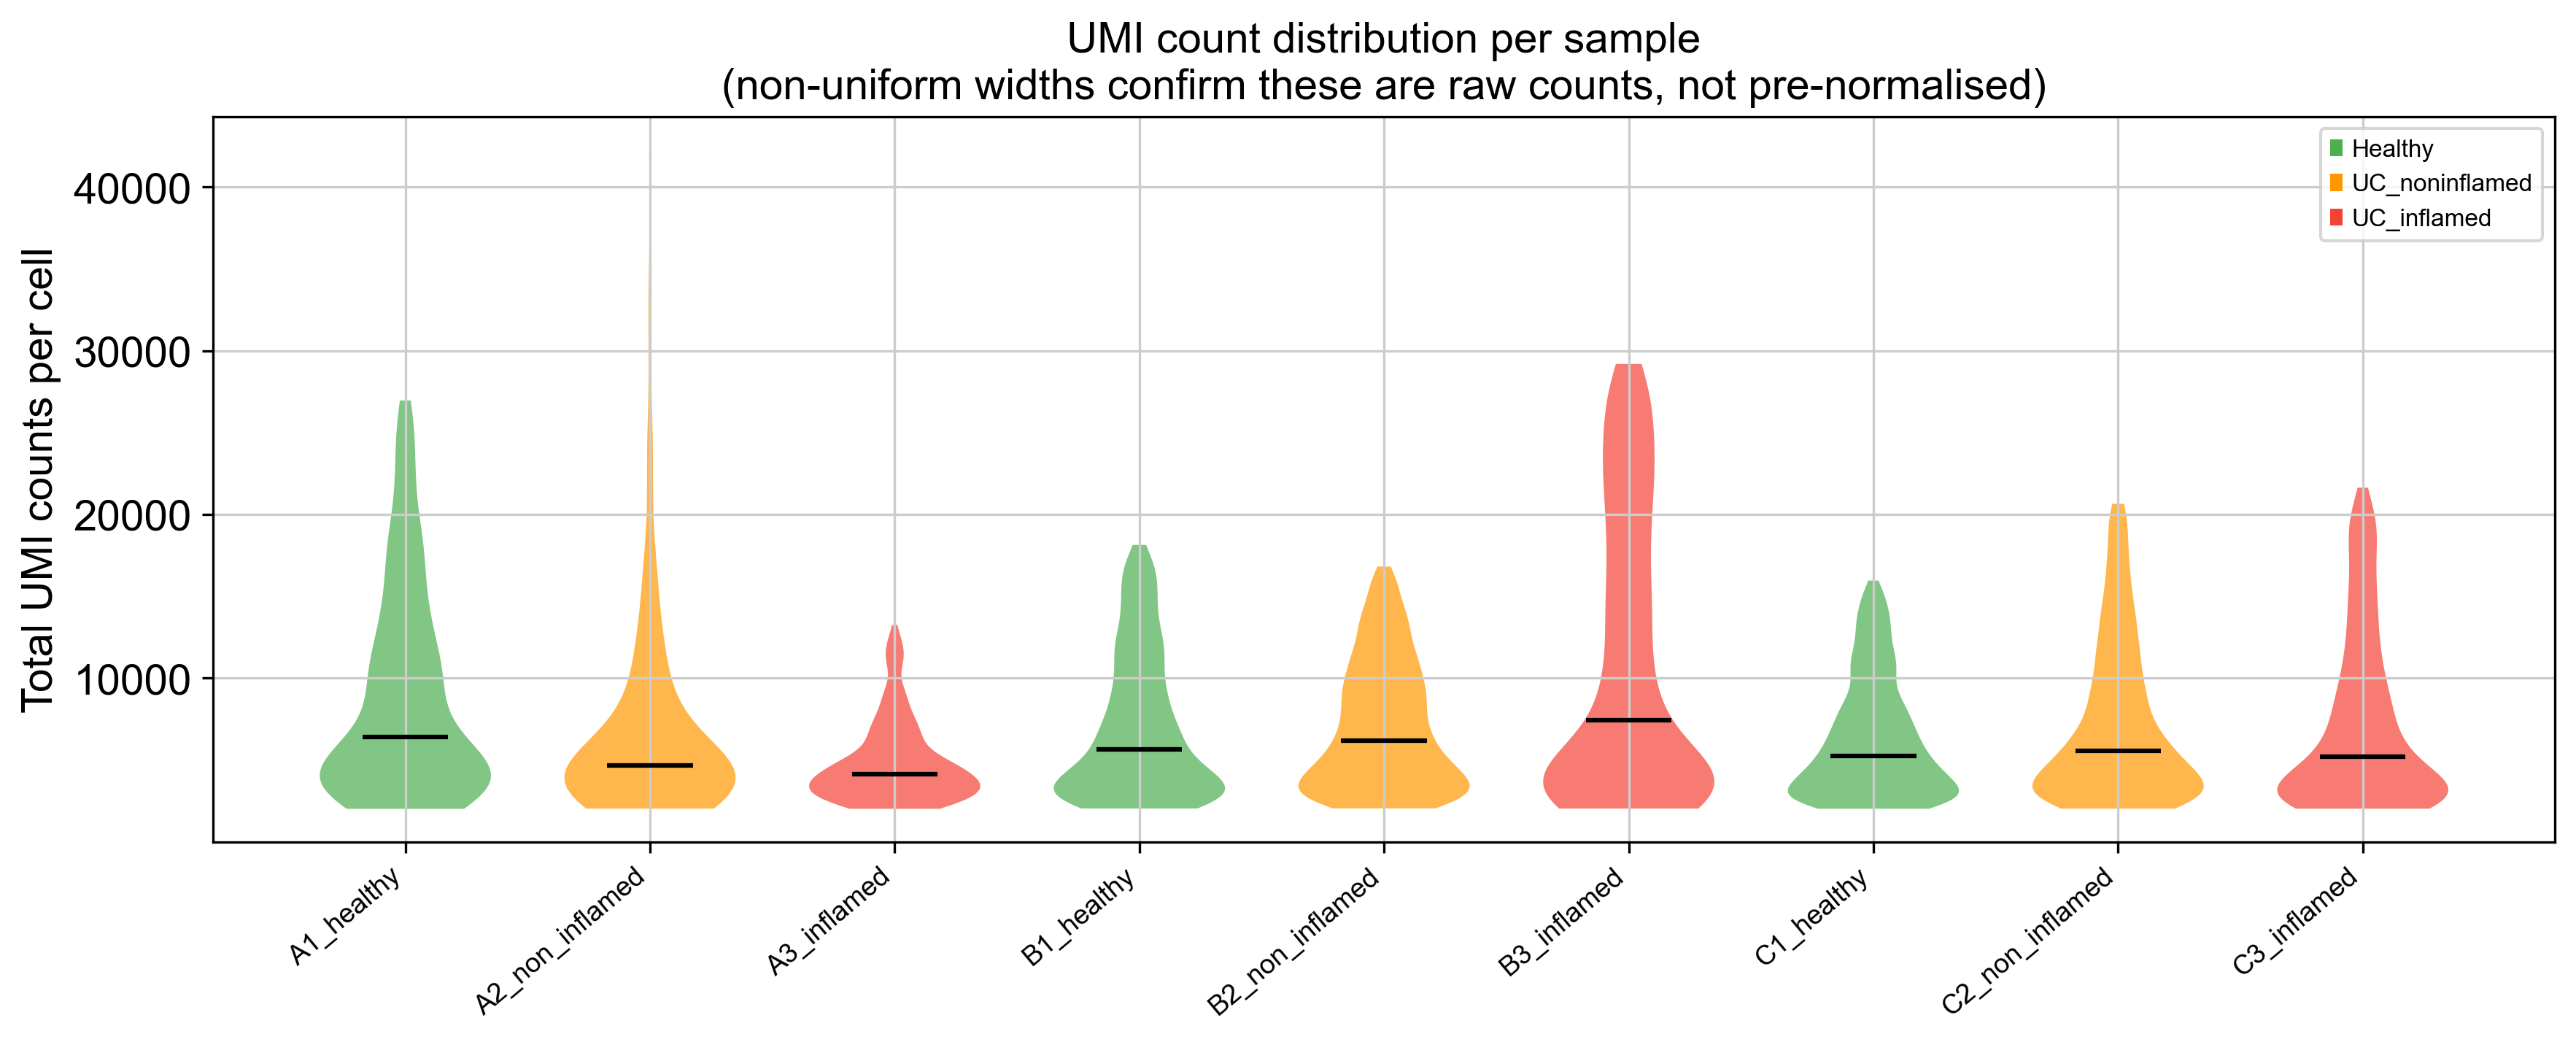

In [11]:
# Collect total UMI counts per cell for each sample
cell_sums_by_sample = {
    s: np.array(merged[merged.obs['sample'] == s].X.sum(axis=1)).flatten()
    for s in sample_order
}

fig, ax = plt.subplots(figsize=(12, 5))
parts = ax.violinplot(
    [cell_sums_by_sample[s] for s in sample_order],
    positions=range(len(sample_order)),
    widths=0.7,
    showmedians=True,
    showextrema=False
)

# Colour violins by condition
for body, s in zip(parts['bodies'], sample_order):
    cond = merged.obs[merged.obs['sample'] == s]['condition'].iloc[0]
    body.set_facecolor(condition_colours[cond])
    body.set_alpha(0.7)

parts['cmedians'].set_color('black')
ax.set_xticks(range(len(sample_order)))
ax.set_xticklabels(sample_order, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Total UMI counts per cell')
ax.set_title('UMI count distribution per sample\n'
             '(non-uniform widths confirm these are raw counts, not pre-normalised)')
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('figures/v2/01_umi_distribution_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## Store raw counts layer and save checkpoint

We immediately copy `.X` into `adata.layers['counts']`. This layer is the permanent reference
for the true raw UMI values and is required later by:
- `sc.pp.highly_variable_genes(..., flavor='seurat_v3', layer='counts')` — which expects raw integers
- Pseudobulk differential expression — which sums raw UMIs per sample

After this step, `.X` will be overwritten by normalization and log-transformation in notebook 03.

In [12]:
merged.layers['counts'] = merged.X.copy()

print(f"adata.layers['counts']  dtype : {merged.layers['counts'].dtype}")
print(f"adata.layers['counts']  shape : {merged.layers['counts'].shape}")
print(f"adata.X                 dtype : {merged.X.dtype}")
print(f"\nAnnData summary:")
print(merged)

adata.layers['counts']  dtype : int32
adata.layers['counts']  shape : (11175, 58690)
adata.X                 dtype : int32

AnnData summary:
AnnData object with n_obs × n_vars = 11175 × 58690
    obs: 'sample', 'condition', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    layers: 'counts'


In [14]:
out_path = 'data/processed/v2/GSE116222_v2_raw.h5ad'
merged.write_h5ad(out_path)
print(f"Saved: {out_path}")
print(f"File size: {os.path.getsize(out_path) / 1e6:.1f} MB")

Saved: data/processed/v2/GSE116222_v2_raw.h5ad
File size: 321.2 MB
